In [1]:
#pip install networkx

In [3]:
# Import necessary libraries
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms.community import girvan_newman

#### Construct graph and compute basic statistics

In [4]:
def load_facebook_network(file_path):
    """
    Loads the Facebook dataset into a NetworkX graph.
    """
    # Read edge list (each line contains two connected node IDs)
    G = nx.read_edgelist(file_path, nodetype=int)
    return G

In [5]:
file_path = "facebook_combined-1 (1).txt"
G = load_facebook_network(file_path)

print(G)  # print to confirm that the graph loaded correctly

Graph with 4039 nodes and 88234 edges


In [59]:
# Check if the graph is directed or undirected
print("Is the graph directed?", G.is_directed())

Is the graph directed? False


The graph is undirected, which matches Facebook friendships because they are mutual connections.

In [64]:
#Compute the basic network properties

# Number of nodes
num_nodes = G.number_of_nodes()

# Number of edges
num_edges = G.number_of_edges()

# Network density (how connected the network is overall)
density = nx.density(G)

# Average degree (average number of connections per node)
avg_degree = (2 * num_edges) / num_nodes

print("Number of nodes:", num_nodes)
print("Number of edges:", num_edges)
print("Network density:", density)
print("Average degree:", avg_degree)

Number of nodes: 4039
Number of edges: 88234
Network density: 0.010819963503439287
Average degree: 43.69101262688784


#### Visualise the network

In [52]:
# Creat a function to visualise network
def plot_network_sample(G, sample_size=500, seed=42):
    """
    Plots a small sample of the network since the full Facebook graph is large.
    """
    # Select a small portion of nodes to make the plot readable
    sample_nodes = list(G.nodes())[:sample_size]
    H = G.subgraph(sample_nodes)

    # Layout algorithm to spread nodes out nicely
    pos = nx.spring_layout(H, seed=seed)

    # Plot the sample network
    plt.figure(figsize=(10, 7))
    nx.draw(H, pos, node_size=20, with_labels=False)
    plt.title(f"Facebook Network Sample ({sample_size} nodes)")
    plt.show()

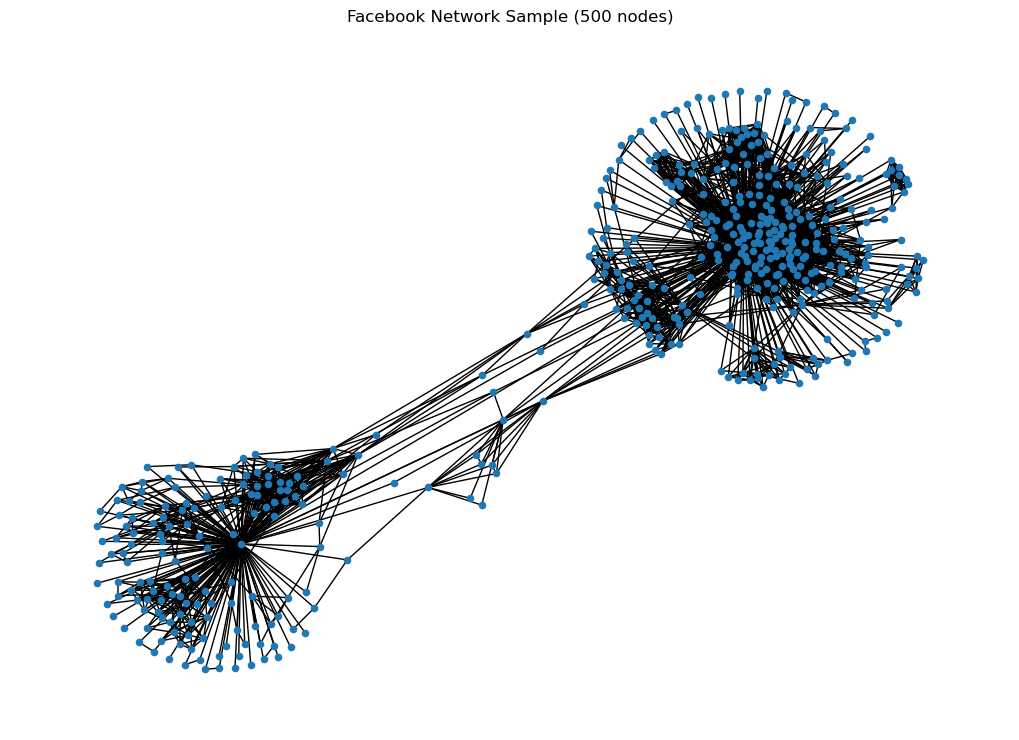

In [66]:
# Apply function to plot network
plot_network_sample(G, sample_size=500)

The Facebook friendship network contains 4,039 nodes (users) and 88,234 edges (friendship connections).  
The network density is 0.0108, which is very low, meaning the network is sparse, most users are not directly connected to most other users.

However, the average degree is 43.69, showing that each user is connected to about 44 friends on average, so even though the network is not fully connected, users still have many friendships within smaller groups.

For the visualisation, a sample of 500 nodes was plotted to avoid overcrowding since the full graph is large. The plot shows clusters of users, suggesting the presence of friendship circles or communities within the network.

#### Degree Distribution

In [65]:
# Extract the degree (number of connections) for every node in the graph
degree_values = [deg for node, deg in G.degree()]

# Get the unique degree values sorted in ascending order
values = sorted(set(degree_values))

# Count how many nodes have each degree value
hist = [degree_values.count(x) for x in values]

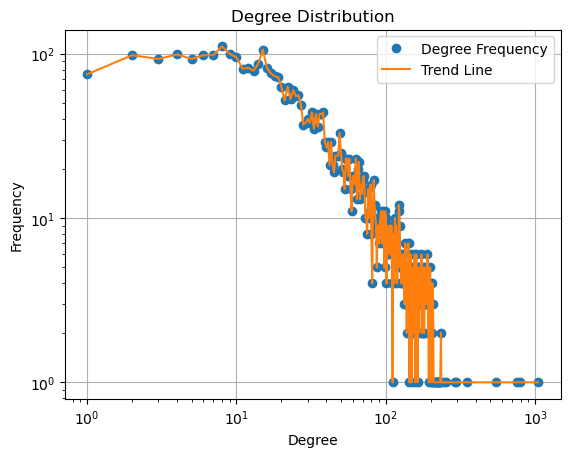

In [8]:
# Plot the degree distribution as scatter points (degree vs frequency)
plt.loglog(values, hist, marker='o', linestyle='none', label="Degree Frequency")

# Plot a line to show the trend more clearly
plt.loglog(values, hist, linestyle='-', label="Trend Line")

# Add labels and title
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.title("Degree Distribution")

# Add grid and legend for readability
plt.grid()
plt.legend()

plt.show()  

The degree distribution shows that most users(nodes) have few connections, while only a small number of users have very high connections. As the degree (number of connections) increases, the number of people with that degree drops sharply. This pattern suggests a hub-like structure, where a few highly connected nodes act as central points that help link different parts of the network together.

In [19]:
# Compute edge betweenness centrality for all edges in the network
# (this shows how important each edge is for connecting different parts of the network)
edge_centrality = nx.edge_betweenness_centrality(G)

# show first 5 edges for check
list(edge_centrality.items())[:5]

[((0, 1), 0.00040049937955461345),
 ((0, 2), 0.0004923848145417046),
 ((0, 3), 0.0004287786850298508),
 ((0, 4), 0.000494007105805077),
 ((0, 5), 0.0004102707367255275)]

In [28]:
def plot_edge_centrality_distribution(edge_centrality, bins=50):
    """
    Plots the distribution of edge betweenness centrality values using a log-scaled y-axis.
    """

    # Extract only the centrality values from the dictionary
    centrality_values = list(edge_centrality.values())

    # Create the histogram plot
    plt.figure(figsize=(10, 6))
    plt.hist(centrality_values, bins=bins)

    # Add labels and title
    plt.title("Distribution of Edge Betweenness Centrality")
    plt.xlabel("Edge Betweenness Centrality")
    plt.ylabel("Frequency (log scale)")

    # Apply log scale to y-axis
    plt.yscale("log")
    
    plt.show()

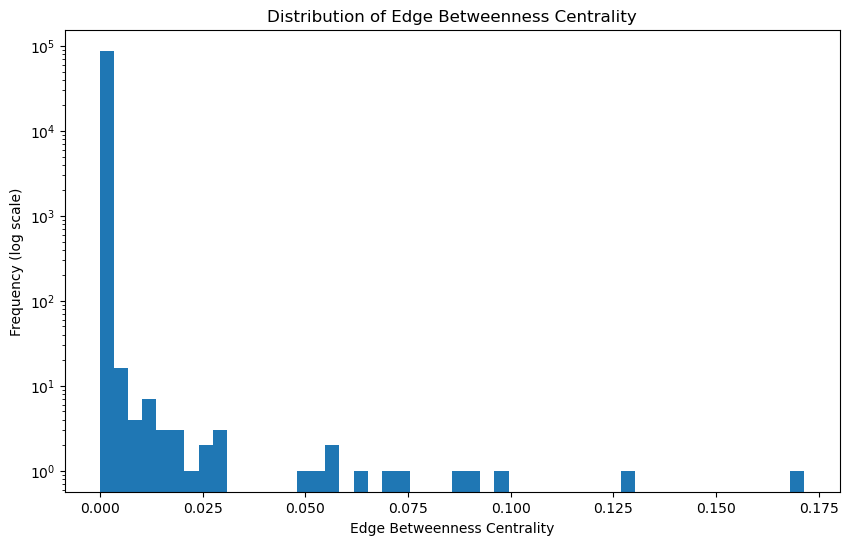

In [29]:
# Apply function to plot edge centrality
plot_edge_centrality_distribution(edge_centrality, bins=50)

The histogram shows the distribution of edge betweenness centrality values in the Facebook network (frequency is shown on a log scale). Most edges have values **very close to 0**, meaning the majority of friendships are local connections within small groups and do not lie on many shortest paths.

Only a small number of edges have **high edge betweenness centrality**, as shown on the right side of the plot. These edges act as **bridge connections** that link different friendship clusters together. This suggests that the network has a **community-based structure**, where few key connections play an important role in keeping the overall network connected. 

Girvan–Newman was chosen because it identifies communities by removing edges with high edge betweenness centrality, which act like “bridges” linking different friendship groups. It can be computationally expensive on large networks, so only early splits are typically analysed.

Label Propagation was also chosen because it is computationally efficient for large networks and can quickly identify densely connected clusters. This makes it suitable for detecting friendship clusters in social network graphs. However, its results may vary slightly each time it runs because the method can be non-deterministic.

#### Girvan–Newman Community Detection
Created a function that runs Girvan–Newman algorithm on a sampled subgraph. It returns the number of communities detected.

In [42]:
def run_girvan_newman_sample(G, level=1, sample_size=500):
    """
    Runs the Girvan–Newman community detection algorithm on a sampled subgraph  and returns communities
    at a chosen level..
    """
    # Take a sample of nodes
    sampled_nodes = list(G.nodes())[:sample_size]

    # Create a subgraph from the sampled nodes
    G_sample = G.subgraph(sampled_nodes).copy()

    # Generate communities step-by-step (hierarchical splitting)
    community_generator = girvan_newman(G_sample)

    # Move through the generator until the desired level is reached
    communities = None
    for _ in range(level):
        communities = next(community_generator)

    return G_sample, list(communities)     # Convert tuple of sets into a list for easier handling

In [43]:
# Run Girvan–Newman on a sample of 500 nodes (level 1 = 2 communities)
G_sample, gn_communities = run_girvan_newman_sample(G, level=1, sample_size=500)

print("Sample graph size:", G_sample.number_of_nodes(), "nodes,", G_sample.number_of_edges(), "edges")
print("Number of communities detected:", len(gn_communities))

Sample graph size: 500 nodes, 3513 edges
Number of communities detected: 2


In [44]:
# Create function to get community size
def get_community_sizes(communities):
    """
    Returns community sizes sorted from largest to smallest.
    """
     # Count how many nodes are in each community
    sizes = [len(c) for c in communities]
    return sorted(sizes, reverse=True)

In [45]:
# Apply the get community size function
gn_sizes = get_community_sizes(gn_communities)

print("Community sizes (largest to smallest):")
print(gn_sizes)

Community sizes (largest to smallest):
[352, 148]


In [56]:
# Create a function to plot sampled communities for both Girvan–Newman and Label Propagation
def plot_communities_sample(G, communities, sample_size=300, seed=42, title="Community Plot (Sample)"):
    """
    Plots a sampled subgraph of the network and colours nodes by detected communities.
    Works for both Girvan–Newman and Label Propagation communities.
    """

    # Map each node to its community ID for colouring
    node_to_community = {}
    for community_id, community_nodes in enumerate(communities):
        for node in community_nodes:
            node_to_community[node] = community_id

    # Sample nodes for a cleaner visualisation (since graph is large)
    sampled_nodes = list(G.nodes())[:sample_size]
    H = G.subgraph(sampled_nodes).copy()

    # Assign each node a colour based on its community ID
    node_colors = [node_to_community.get(node, -1) for node in H.nodes()]

    # Layout for plotting
    pos = nx.spring_layout(H, seed=seed)

    # Plot the sampled network
    plt.figure(figsize=(10, 8))
    nx.draw(
        H,
        pos,
        node_size=30,
        node_color=node_colors,
        cmap=plt.cm.Set3,
        with_labels=False,
        edge_color="gray",
        alpha=0.6
    )

    plt.title(f"{title} ({sample_size} nodes)")
    plt.axis("off")
    plt.show()

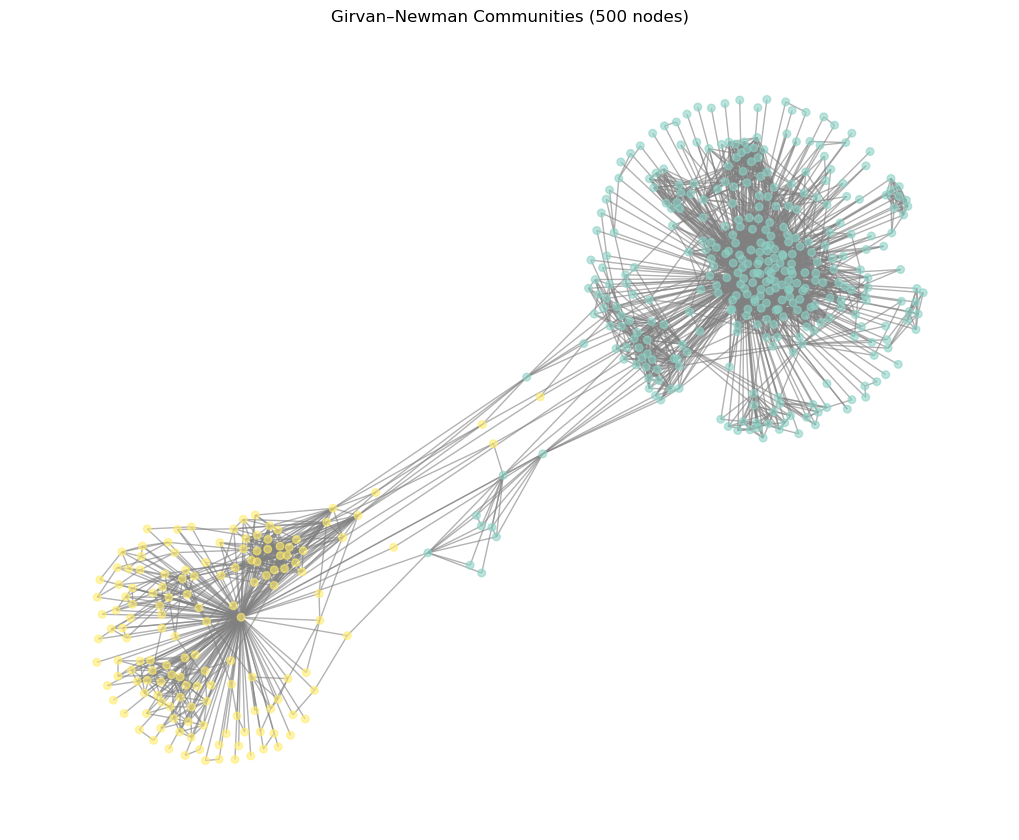

In [57]:
# Apply function to plot Girvan–Newman community
plot_communities_sample(G_sample, gn_communities, sample_size=500,
                        title="Girvan–Newman Communities")

#### Using another split level (level 2 which gives 3 communities)

In [32]:
# Run Girvan–Newman on a sample of 500 nodes (level 2 = 3 communities)
G_sample, gn_communities2 = run_girvan_newman_sample(G, level=2, sample_size=500)

print("Sample graph size:", G_sample.number_of_nodes(), "nodes,", G_sample.number_of_edges(), "edges")
print("Number of communities detected:", len(gn_communities2))

Sample graph size: 500 nodes, 3513 edges
Number of communities detected: 3


In [33]:
# Apply the get community size function
gn_sizes2 = get_community_sizes(gn_communities2)

print("Community sizes (largest to smallest):")
print(gn_sizes2)

Community sizes (largest to smallest):
[343, 148, 9]


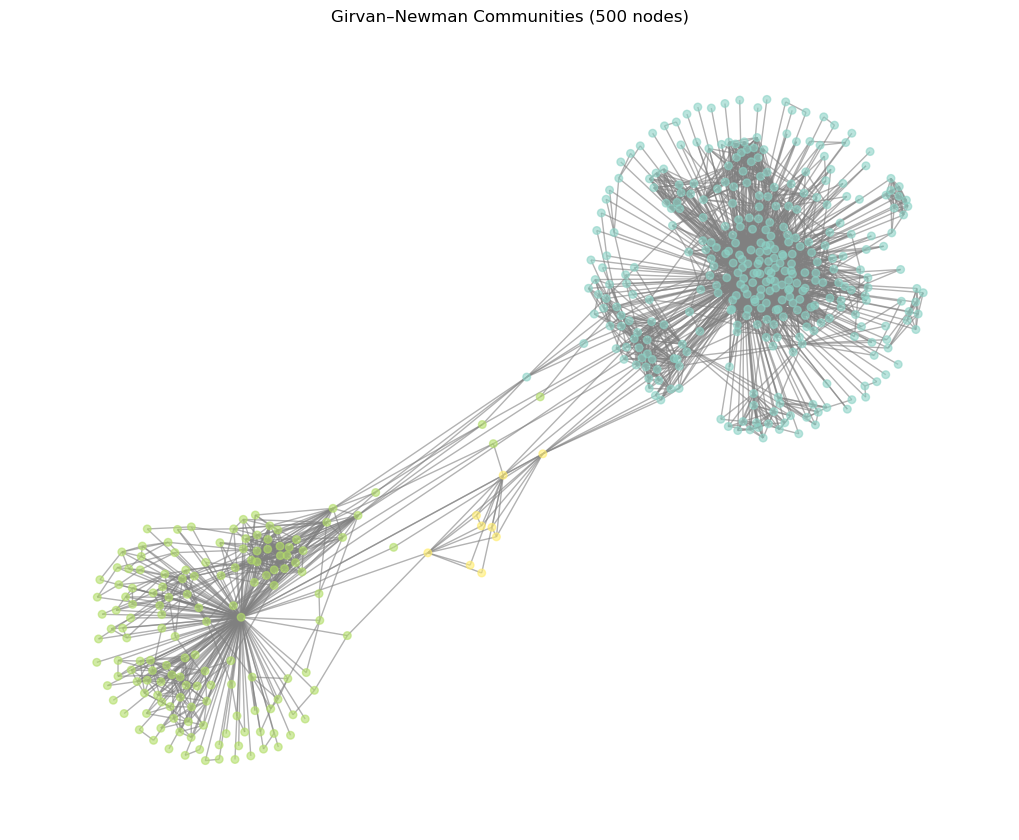

In [48]:
# Apply function to plot Girvan–Newman community
plot_communities_sample(G_sample, gn_communities2, sample_size=500,
                        title="Girvan–Newman Communities")

#### Label Propagation Community Detection
Created a funtion that runs LPA to detect communities in the graph. This function returns a list of communities detected.

In [49]:
# Create a function for label propagation
def run_label_propagation(G):
    """
    Runs Label Propagation Algorithm (LPA) to detect communities in the graph and returns A list of communities, 
    where each community is a set of nodes.
    """
    
    # Detect communities using Label Propagation
    communities = nx.community.label_propagation_communities(G)
    
    # Convert generator output into a list for easier use
    return list(communities)

In [50]:
lpa_communities = run_label_propagation(G)

print("Number of communities detected (Label Propagation):", len(lpa_communities))
print("Community sizes (largest to smallest):", get_community_sizes(lpa_communities))

Number of communities detected (Label Propagation): 44
Community sizes (largest to smallest): [1030, 753, 547, 469, 226, 215, 198, 179, 60, 49, 36, 34, 25, 19, 16, 14, 13, 12, 10, 10, 10, 9, 9, 8, 8, 8, 8, 7, 7, 6, 6, 6, 4, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2]


##### Visualise Label Propagation Communities

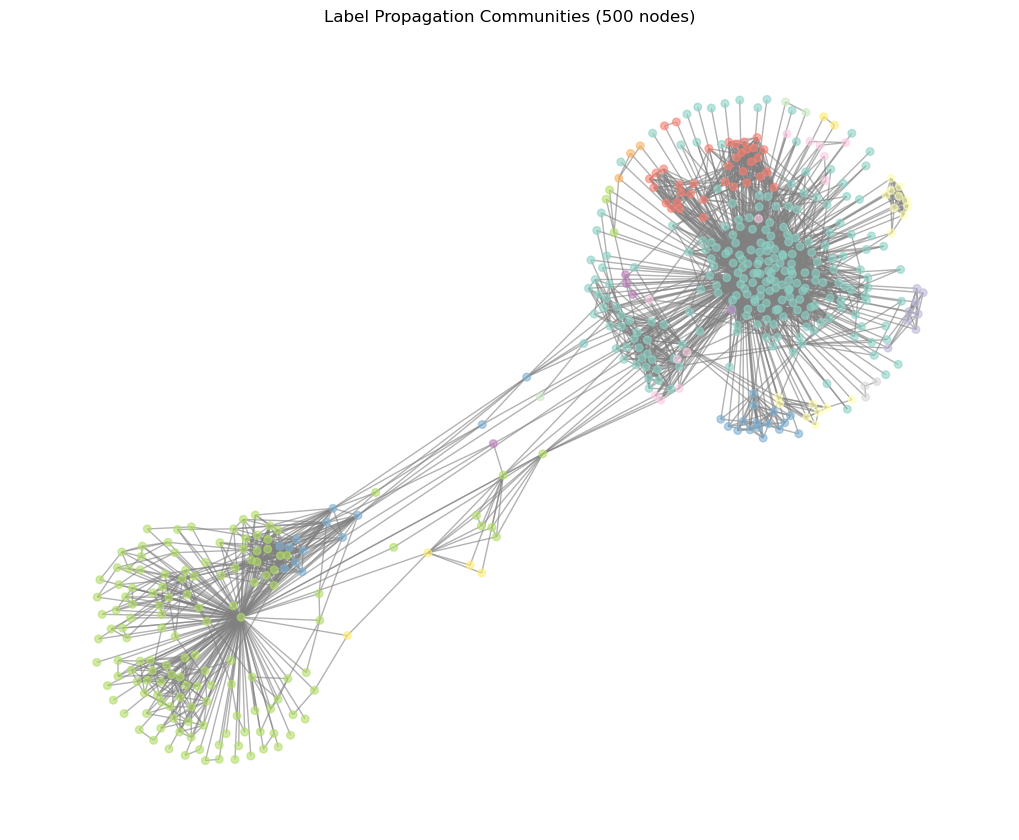

In [51]:
# Apply function to plot Label Propagation community
plot_communities_sample(G, lpa_communities, sample_size=500,
                        title="Label Propagation Communities")

Two community detection algorithms were applied to the Facebook friendship network to identify friendship circles.

**Girvan–Newman (sampled graph)** was run on a subgraph of **500 nodes and 3,513 edges** due to the high computational cost of running it on the full network.  
At the first split, it detected **2 communities**, with sizes **352** and **148** nodes.  
At the second split, it detected **3 communities**, with sizes **343**, **148**, and **9** nodes.  

This shows that Girvan–Newman initially separates the sample into large groups, and with further splitting it begins to isolate smaller sub-communities.

**Label Propagation (full graph)** was run on the full network and detected **44 communities**. The community sizes vary widely, with the largest communities containing **1,030**, **753**, **547**, and **469** nodes, while many smaller communities contain fewer than 10 nodes. This suggests the network contains multiple friendship circles of different sizes rather than only a few large groups.

Generally, Girvan–Newman produces fewer, broader communities (especially at early split levels), while Label Propagation identifies many more communities and provides a more detailed view of clustering in the friendship network.